---
## ⚙️ STEP 1 — Install Dependencies

In [1]:
# Install Ultralytics (includes YOLOv8) and other utilities
!pip install ultralytics --quiet
!pip install matplotlib Pillow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from pathlib import Path
import shutil
import yaml
from ultralytics import YOLO
import shutil, os
import cv2, random
import matplotlib.pyplot as plt


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# ─────────────────────────────────────────────────────────
# 🔧 TRAINING CONFIG — adjust as needed
# ─────────────────────────────────────────────────────────
MODEL_WEIGHTS = 'yolov8n.pt'
EPOCHS        = 100
IMAGE_SIZE    = 256
BATCH_SIZE    = 32
# ─────────────────────────────────────────────────────────

---
## 📂 STEP 2 — Mount Google Drive & Load Dataset

### download dataset from: [coin dataset](https://s3.us-west-1.amazonaws.com/evanjuras.com/resources/YOLO_coin_data_12DEC30.zip)

In [4]:
# Mount your Google Drive — a browser auth popup will appear
drive.mount('/content/drive')

print("✅ Google Drive mounted at /content/drive")

Mounted at /content/drive
✅ Google Drive mounted at /content/drive


In [5]:
# ─────────────────────────────────────────────────────────
# 🔧 CONFIGURE THIS: path to your dataset folder in Drive
# ─────────────────────────────────────────────────────────
DRIVE_DATASET_PATH = '/content/drive/MyDrive/dataset/coin_dataset'

# class names from classes.txt
classes_txt = os.path.join(DRIVE_DATASET_PATH, 'classes.txt')

with open(classes_txt, 'r') as f:
    CLASS_NAMES = [line.strip() for line in f.readlines() if line.strip()]

# Find all images
images = glob.glob(os.path.join(DRIVE_DATASET_PATH, '**', '*.jpg'),  recursive=True) + \
             glob.glob(os.path.join(DRIVE_DATASET_PATH, '**', '*.JPG'),  recursive=True)

# Find all labels
labels = [f for f in glob.glob(os.path.join(DRIVE_DATASET_PATH, 'labels', '*.txt'))
          if os.path.basename(f) != 'classes.txt']

print(f"\n✅ Found {len(images)} images")
print(f"✅ Found {len(labels)} label (.txt) files")

if len(images) == 0:
    print("⚠️  No images found — check your DRIVE_DATASET_PATH above!")


✅ Found 750 images
✅ Found 750 label (.txt) files


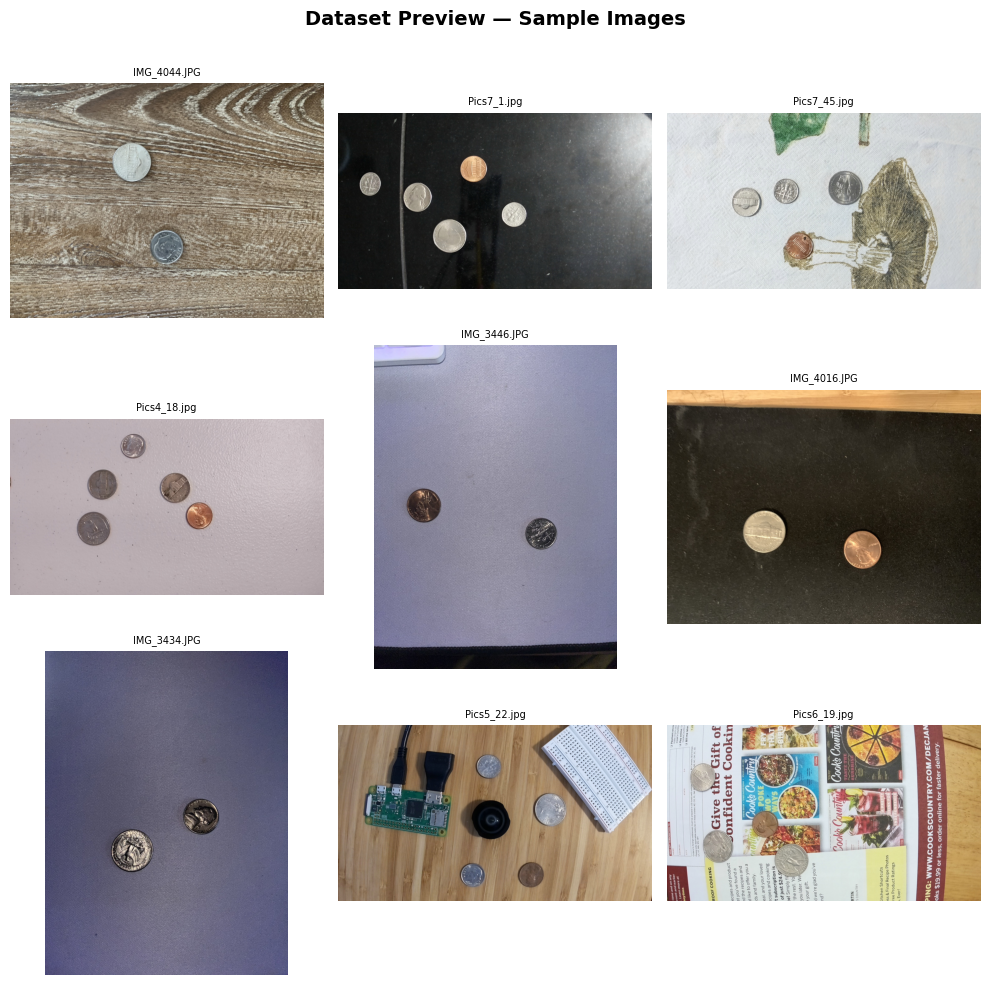

In [6]:
# Preview a sample of images from your dataset
sample = random.sample(images, min(9, len(images)))

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Dataset Preview — Sample Images', fontsize=14, fontweight='bold')

for ax, img_path in zip(axes.flatten(), sample):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path), fontsize=7)
    ax.axis('off')

# Hide unused axes if fewer than 9 images
for ax in axes.flatten()[len(sample):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 🗂️ STEP 3 — Build YOLO Directory Structure

Ultralytics expects this layout:
```
dataset/
├── images/
│   ├── train/    ← 80% of images
│   └── val/      ← 20% of images
└── labels/
    ├── train/    ← matching .txt annotation files
    └── val/      ← matching .txt annotation files
```
Each `.txt` label file has one row per object: `class_id cx cy width height` (all normalized 0–1)

In [7]:
BASE_DIR = Path('/content/dataset')

# Create all required directories
for split in ['train', 'val']:
    (BASE_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (BASE_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

print("✅ Directory structure created:")
for p in sorted(BASE_DIR.rglob('*')):
    level = len(p.relative_to(BASE_DIR).parts)
    print('   ' + '│   ' * (level - 1) + '├── ' + p.name + ('/' if p.is_dir() else ''))

✅ Directory structure created:
   ├── images/
   │   ├── train/
   │   ├── val/
   ├── labels/
   │   ├── train/
   │   ├── val/


In [ ]:
# # Shuffle and split
# random.seed(42)
# random.shuffle(images)

# split_idx  = int(len(images) * 0.8)
# train_imgs = images[:split_idx]
# val_imgs   = images[split_idx:]

# # Copy train
# for img_path in train_imgs:
#     img_path   = Path(img_path)
#     label_path = Path(DRIVE_DATASET_PATH) / 'labels' / (img_path.stem + '.txt')
#     shutil.copy(img_path,   BASE_DIR / 'images' / 'train' / img_path.name)
#     shutil.copy(label_path, BASE_DIR / 'labels' / 'train' / label_path.name)

# # Copy val
# for img_path in val_imgs:
#     img_path   = Path(img_path)
#     label_path = Path(DRIVE_DATASET_PATH) / 'labels' / (img_path.stem + '.txt')
#     shutil.copy(img_path,   BASE_DIR / 'images' / 'val' / img_path.name)
#     shutil.copy(label_path, BASE_DIR / 'labels' / 'val' / label_path.name)

# print(f"✅ Train : {len(train_imgs)} images + labels")
# print(f"✅ Val   : {len(val_imgs)} images + labels")

In [8]:
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import shutil

split_idx  = int(len(images) * 0.8)
train_imgs = images[:split_idx]
val_imgs   = images[split_idx:]

def copy_pair(img_path, split):
    img_path = Path(img_path)
    label_path = Path(DRIVE_DATASET_PATH) / 'labels' / (img_path.stem + '.txt')
    shutil.copy(img_path, BASE_DIR / 'images' / split / img_path.name)
    shutil.copy(label_path, BASE_DIR / 'labels' / split / label_path.name)

def copy_all(img_list, split, max_workers=16):
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        list(ex.map(lambda p: copy_pair(p, split), img_list))

copy_all(train_imgs, 'train')
copy_all(val_imgs, 'val')

print(f"✅ Train : {len(train_imgs)} images + labels")
print(f"✅ Val   : {len(val_imgs)} images + labels")

✅ Train : 600 images + labels
✅ Val   : 150 images + labels


---
## 📄 STEP 4 — Write data.yaml Config

This file tells Ultralytics where your data lives and what classes to detect.

In [9]:
data_config = {
    'path'  : str(BASE_DIR.resolve()),    # absolute path to dataset root
    'train' : 'images/train',
    'val'   : 'images/val',
    'nc'    : len(CLASS_NAMES),           # number of classes
    'names' : CLASS_NAMES
}

yaml_path = BASE_DIR / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

# Print for verification
print("✅ data.yaml written:\n")
with open(yaml_path) as f:
    print(f.read())

✅ data.yaml written:

names:
- penny
- nickel
- dime
- quarter
nc: 4
path: /content/dataset
train: images/train
val: images/val



---
## 🚀 STEP 5 — Fine-tune YOLOv8

We load a **pre-trained** YOLOv8 nano model and fine-tune it on our custom dataset.  
This is **transfer learning** — the model already knows edges, textures, shapes. We're teaching it your specific classes.

| Model | Size | Speed | Accuracy |
|-------|------|-------|----------|
| yolov8n | ~6MB | ⚡⚡⚡ | Good |
| yolov8s | ~22MB | ⚡⚡ | Better |
| yolov8m | ~52MB | ⚡ | Best |

In [10]:
# Load pre-trained model
model = YOLO(MODEL_WEIGHTS)
print(f"✅ Loaded pre-trained model: {MODEL_WEIGHTS}")

# Start fine-tuning
results = model.train(
    data      = str(yaml_path),
    epochs    = EPOCHS,
    imgsz     = IMAGE_SIZE,
    batch     = BATCH_SIZE,
    project   = '/content/runs',
    name      = 'finetune',
    exist_ok  = True,
    patience  = 10,           # early stopping if no improvement for 10 epochs
    save      = True,
    plots     = True,         # auto-generates loss curves & metric charts
    verbose   = False
)

print("\n✅ Training complete!")
print(f"📁 Results saved to: /content/runs/finetune/")

✅ Loaded pre-trained model: yolov8n.pt
Ultralytics 8.4.94 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune, nbs=64, nms=False, opset=None, optimize

---
## 💾 STEP 6 — Save Fine-tuned Model Back to Drive

In [11]:
save_dir    = '/content/drive/MyDrive/dataset/yolo_finetuned'
best_weights = '/content/runs/finetune/weights/best.pt'

os.makedirs(save_dir, exist_ok=True)
shutil.copy(best_weights, os.path.join(save_dir, 'best.pt'))

print(f"✅ Fine-tuned model saved to: {save_dir}/best.pt")

✅ Fine-tuned model saved to: /content/drive/MyDrive/dataset/yolo_finetuned/best.pt


---
## 🖼️ STEP 7 — Test Inference on New Images

Now we run the **fine-tuned model** on unseen test images and visualise the bounding boxes.  
We also compare against the **base pre-trained model** to show how much finetuning helped.

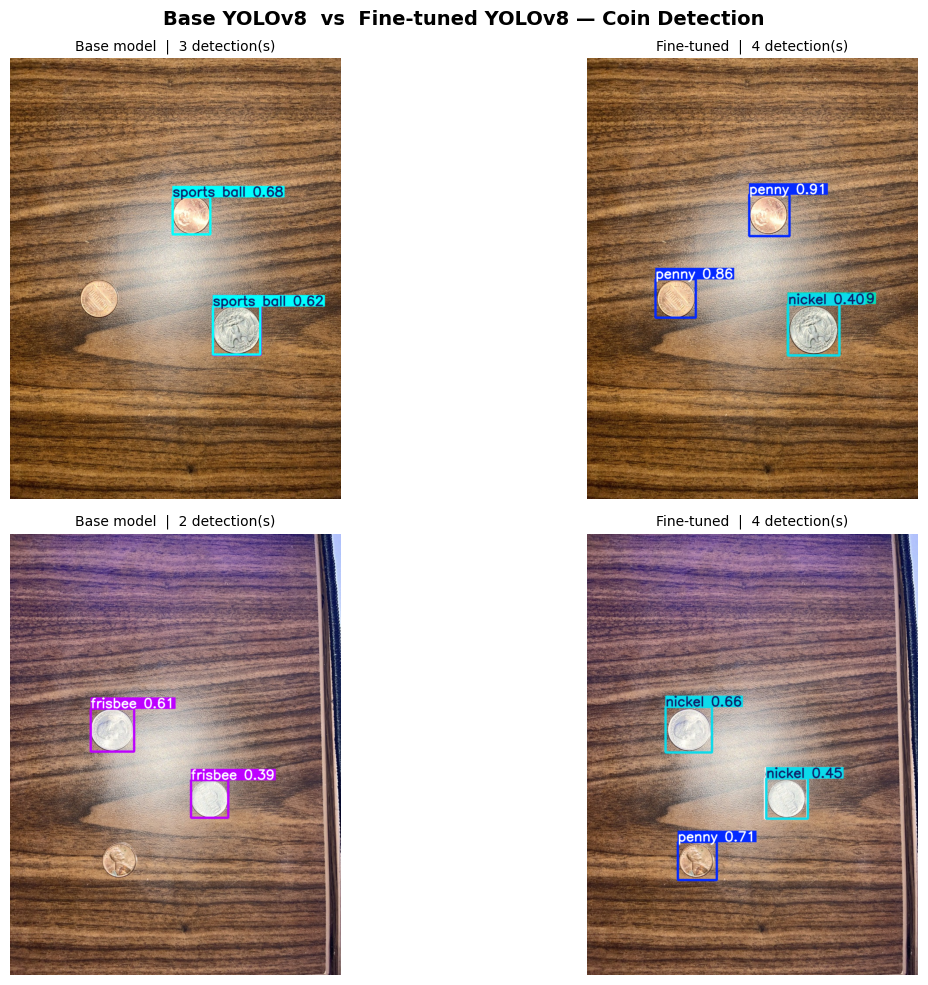

In [12]:
# ── pick 2 random val images ──
test_sample = random.sample(val_imgs, 2)
base_model = YOLO(MODEL_WEIGHTS)  # original pretrained weights
finetuned_model = YOLO(save_dir+'/best.pt')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Base YOLOv8  vs  Fine-tuned YOLOv8 — Coin Detection', fontsize=14, fontweight='bold')
for row, img_path in enumerate(test_sample):
    # Base model
    base_result = base_model.predict(img_path, conf=0.25, verbose=False)
    base_ann    = cv2.cvtColor(base_result[0].plot(), cv2.COLOR_BGR2RGB)
    base_n      = len(base_result[0].boxes or [])
    # Fine-tuned model
    tuned_result = finetuned_model.predict(img_path, conf=0.25, verbose=False)
    tuned_ann    = cv2.cvtColor(tuned_result[0].plot(), cv2.COLOR_BGR2RGB)
    tuned_n      = len(tuned_result[0].boxes or [])
    axes[row, 0].imshow(base_ann)
    axes[row, 0].set_title(f'Base model  |  {base_n} detection(s)', fontsize=10)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(tuned_ann)
    axes[row, 1].set_title(f'Fine-tuned  |  {tuned_n} detection(s)', fontsize=10)
    axes[row, 1].axis('off')
# Row labels on the left
for row, img_path in enumerate(test_sample):
    axes[row, 0].set_ylabel(f'Image {row+1}: {os.path.basename(img_path)}',
                             fontsize=8, rotation=90, labelpad=10)
plt.tight_layout()
plt.show()

---
## 🖼️ STEP 8 — Test Inference on New Images (5 epoch)

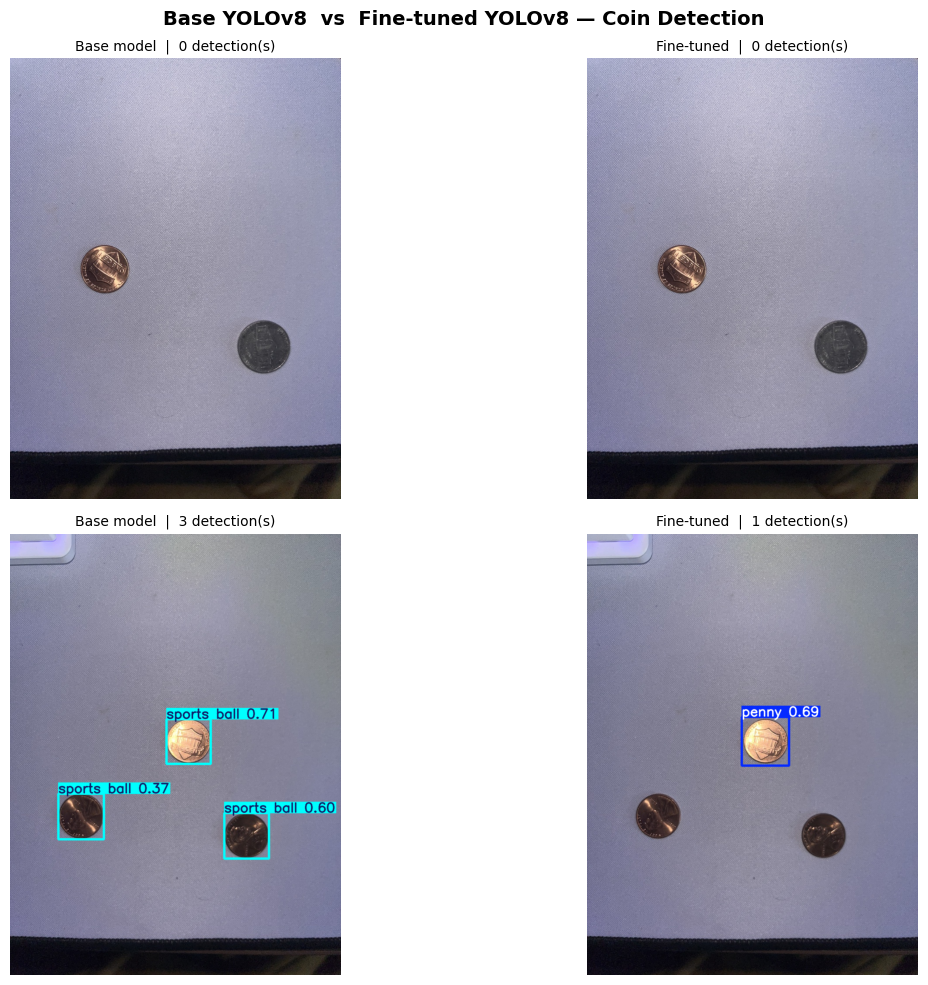

In [ ]:
# ── pick 2 random val images ──
# test_sample = random.sample(val_imgs, 2)
base_model = YOLO(MODEL_WEIGHTS)  # original pretrained weights
finetuned_model = YOLO("/content/drive/MyDrive/Colab Notebooks/Ostad/Module_16_batch_6/yolo_finetuned_5_epochs/best.pt")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Base YOLOv8  vs  Fine-tuned YOLOv8 — Coin Detection', fontsize=14, fontweight='bold')
for row, img_path in enumerate(test_sample):
    # Base model
    base_result = base_model.predict(img_path, conf=0.25, verbose=False)
    base_ann    = cv2.cvtColor(base_result[0].plot(), cv2.COLOR_BGR2RGB)
    base_n      = len(base_result[0].boxes or [])
    # Fine-tuned model
    tuned_result = finetuned_model.predict(img_path, conf=0.25, verbose=False)
    tuned_ann    = cv2.cvtColor(tuned_result[0].plot(), cv2.COLOR_BGR2RGB)
    tuned_n      = len(tuned_result[0].boxes or [])
    axes[row, 0].imshow(base_ann)
    axes[row, 0].set_title(f'Base model  |  {base_n} detection(s)', fontsize=10)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(tuned_ann)
    axes[row, 1].set_title(f'Fine-tuned  |  {tuned_n} detection(s)', fontsize=10)
    axes[row, 1].axis('off')
# Row labels on the left
for row, img_path in enumerate(test_sample):
    axes[row, 0].set_ylabel(f'Image {row+1}: {os.path.basename(img_path)}',
                             fontsize=8, rotation=90, labelpad=10)
plt.tight_layout()
plt.show()